# 04 — Inventory Optimisation: From Forecasts to Reorder Decisions

**Goal**: Translate the LightGBM demand forecast and 80% prediction intervals into
concrete inventory policy parameters and simulate their operational performance.

**Models**:
- *Newsvendor model* — optimal order quantity given asymmetric overage/underage costs
- *Safety stock* — buffer stock sized to a target service level
- *(s, S) continuous-review policy* — reorder to S whenever inventory falls to s
- *Inventory simulation* — empirical service level and cost under stochastic demand

**Dataset**: M5 CA_1 — 3,049 SKUs, trained LightGBM forecast from notebook 03

In [10]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from forecasting.data import load_m5_long, train_test_split
from forecasting.lgbm_model import LGBMForecaster
from forecasting.inventory import (
    std_from_interval,
    newsvendor_quantity,
    safety_stock,
    reorder_point,
    order_up_to_level,
    compute_sku_policies,
    simulate_inventory,
    compute_policy_costs,
    service_level_frontier,
)
from commerce_ml.viz.plotting import apply_style, PALETTE

apply_style()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


## 1. Load data and trained LightGBM model

In [11]:
df   = load_m5_long(store_id="CA_1")
train, test = train_test_split(df, test_days=28)

MODEL_PATH = RESULTS / "lgbm_model.pkl"
model = LGBMForecaster.load(MODEL_PATH)

# Generate forecasts with 80% intervals
preds = model.predict_with_intervals(test)

print(f"Loaded model trained on {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Test period: {test['date'].min().date()} → {test['date'].max().date()}")
print(f"SKUs: {preds['id'].nunique():,}")
print(preds[['forecast','lower_80','upper_80']].describe().round(2))

Loaded model trained on 2011-01-29 → 2016-04-24
Test period: 2016-04-25 → 2016-05-22
SKUs: 3,049
       forecast  lower_80  upper_80
count  85372.00  85372.00  85372.00
mean       1.50      0.13      3.26
std        2.94      0.58      4.58
min        0.00      0.00      0.02
25%        0.32      0.00      1.16
50%        0.71      0.00      2.01
75%        1.47      0.00      3.52
max       96.35      6.82    131.71


## 2. Demand distribution: μ and σ from the forecast intervals

Each SKU's demand uncertainty is estimated from the 80% prediction interval:

$$\hat{\sigma}_i = \frac{\text{upper}_{80,i} - \text{lower}_{80,i}}{2 \times 1.282}$$

This is the same approach used in the (s, S) policy calculations.

SKUs with positive mean demand: 3,049
Median CV: 1.07  (high CV → hard to forecast)
         mean_d     std_d        cv
count  3049.000  3049.000  3049.000
mean      1.500     1.224     1.142
std       2.846     1.573     0.383
min       0.154     0.067     0.377
25%       0.323     0.455     0.895
50%       0.715     0.787     1.068
75%       1.430     1.353     1.322
max      59.306    34.050     4.073


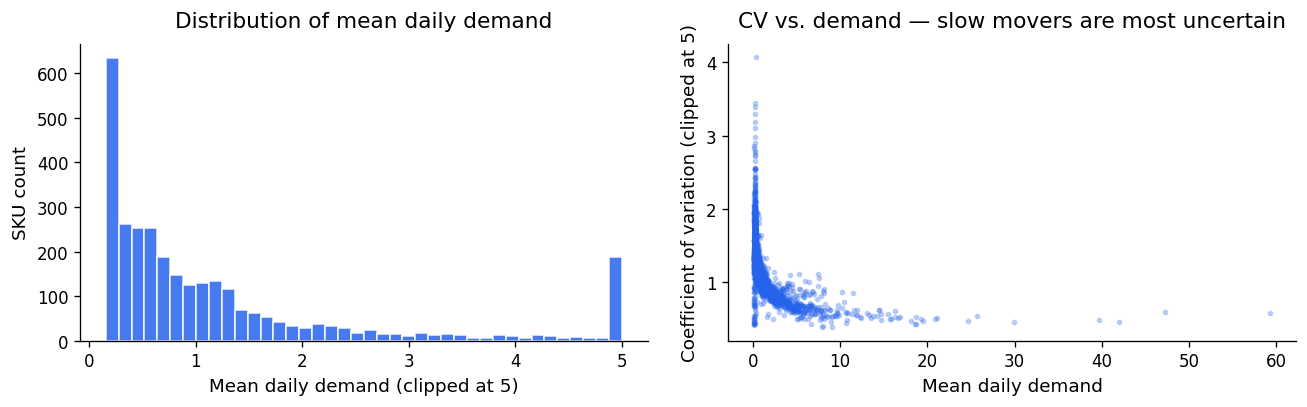

In [12]:
# Per-SKU μ and σ derived from forecast intervals
preds["sku_std"] = (preds["upper_80"] - preds["lower_80"]) / (2 * 1.282)

sku_dist = (
    preds.groupby("id")
    .agg(mean_d=("forecast", "mean"), std_d=("sku_std", "mean"))
    .reset_index()
)
sku_dist["cv"] = sku_dist["std_d"] / (sku_dist["mean_d"] + 1e-9)  # coefficient of variation

print(f"SKUs with positive mean demand: {(sku_dist['mean_d'] > 0).sum():,}")
print(f"Median CV: {sku_dist['cv'].median():.2f}  (high CV → hard to forecast)")
print(sku_dist[["mean_d","std_d","cv"]].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(sku_dist["mean_d"].clip(upper=5), bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Mean daily demand (clipped at 5)")
axes[0].set_ylabel("SKU count")
axes[0].set_title("Distribution of mean daily demand")

axes[1].scatter(sku_dist["mean_d"], sku_dist["cv"].clip(upper=5),
                alpha=0.25, s=6, color=PALETTE[0])
axes[1].set_xlabel("Mean daily demand")
axes[1].set_ylabel("Coefficient of variation (clipped at 5)")
axes[1].set_title("CV vs. demand — slow movers are most uncertain")

plt.tight_layout()
plt.savefig(RESULTS / "inventory_demand_distribution.png", dpi=120)
plt.show()

## 3. (s, S) policy parameters per SKU

**Inputs**: forecasted mean demand, σ, lead time, service level, cost ratio.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Lead time | 7 days | Typical Walmart DC-to-store replenishment |
| Service level | 95% | Industry standard for grocery/household |
| Overage cost | 1.0 | Holding + shrinkage per unit |
| Underage cost | 5.0 | Lost margin + goodwill ($5 per lost sale) |
| Review period | 7 days | Weekly ordering cadence |

In [13]:
LEAD_TIME  = 7    # days
SERVICE_LV = 0.95
COST_OVER  = 1.0  # holding cost per unit
COST_UNDER = 5.0  # stockout penalty per unit
REVIEW     = 7    # days of stock to hold above reorder point

policies = compute_sku_policies(
    preds,
    lead_time_days=LEAD_TIME,
    service_level=SERVICE_LV,
    cost_overstock=COST_OVER,
    cost_understock=COST_UNDER,
    review_period=REVIEW,
)

print(f"Policy parameters for {len(policies):,} SKUs:")
print(policies[["id","mean_daily_demand","std_daily_demand",
                "safety_stock","reorder_point","order_up_to","newsvendor_q"]].head(10).to_string(index=False))

policies.to_csv(RESULTS / "inventory_policies.csv", index=False)
print(f"\nSaved to {RESULTS / 'inventory_policies.csv'}")

Policy parameters for 3,049 SKUs:
                         id  mean_daily_demand  std_daily_demand  safety_stock  reorder_point  order_up_to  newsvendor_q
FOODS_3_090_CA_1_evaluation            59.3061           34.0497        148.18         563.32       978.47        502.30
FOODS_3_120_CA_1_evaluation            47.2473           27.6866        120.49         451.22       781.95        401.60
FOODS_3_586_CA_1_evaluation            42.0250           18.9899         82.64         376.82       670.99        342.78
FOODS_3_252_CA_1_evaluation            39.6707           18.6588         81.20         358.90       636.59        325.45
FOODS_3_064_CA_1_evaluation            29.9505           13.4890         58.70         268.36       478.01        244.18
FOODS_3_282_CA_1_evaluation            25.6802           13.4806         58.67         238.43       418.19        214.27
FOODS_3_587_CA_1_evaluation            24.6508           11.4082         49.65         222.20       394.76        201.7

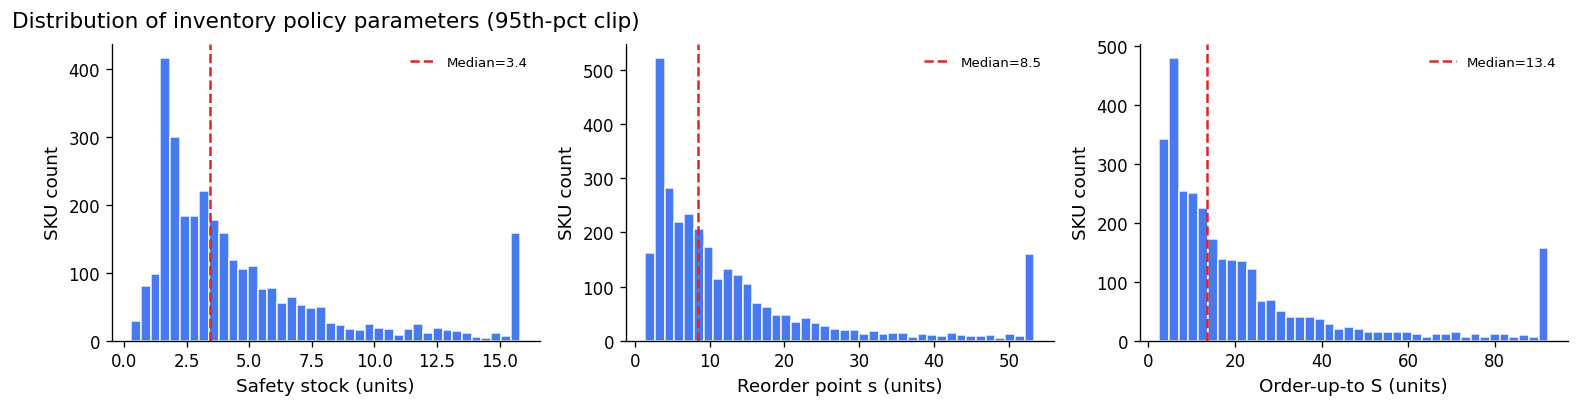

Median safety stock:  3.4 units
Median reorder point: 8.5 units
Median order-up-to:   13.4 units


In [14]:
# Visualise the policy parameter distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, col, title in zip(axes,
    ["safety_stock", "reorder_point", "order_up_to"],
    ["Safety stock (units)", "Reorder point s (units)", "Order-up-to S (units)"]
):
    data = policies[col].clip(upper=policies[col].quantile(0.95))
    ax.hist(data, bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color=PALETTE[2], linestyle="--",
               label=f"Median={data.median():.1f}")
    ax.set_xlabel(title)
    ax.set_ylabel("SKU count")
    ax.legend(fontsize=8)

axes[0].set_title("Distribution of inventory policy parameters (95th-pct clip)")
plt.tight_layout()
plt.savefig(RESULTS / "inventory_policy_distribution.png", dpi=120)
plt.show()

print(f"Median safety stock:  {policies['safety_stock'].median():.1f} units")
print(f"Median reorder point: {policies['reorder_point'].median():.1f} units")
print(f"Median order-up-to:   {policies['order_up_to'].median():.1f} units")

## 4. Service-level trade-off: the cost of availability

Higher service levels require more safety stock. This chart shows the trade-off
for a representative SKU — the "knee" of the curve is typically around 95%.

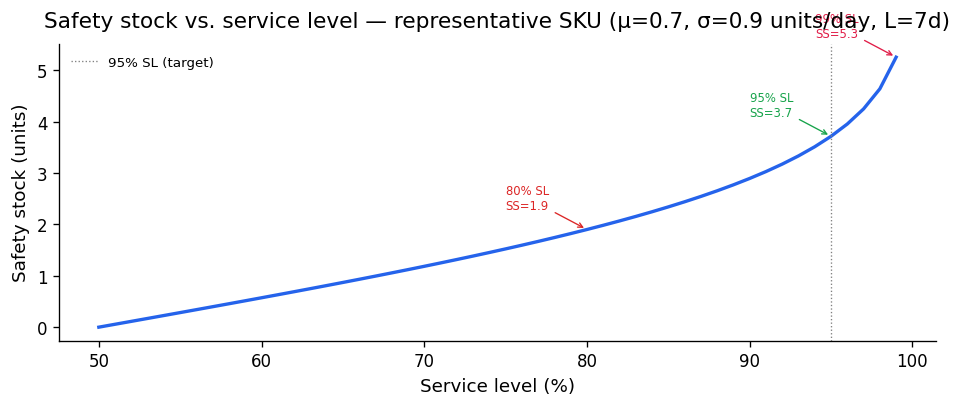

SL=80%  safety_stock=1.90  reorder_point=6.91
SL=90%  safety_stock=2.89  reorder_point=7.90
SL=95%  safety_stock=3.71  reorder_point=8.72
SL=99%  safety_stock=5.25  reorder_point=10.26


In [15]:
# Use a medium-velocity SKU for the illustration
median_sku = policies.iloc[len(policies) // 2]
mu  = median_sku["mean_daily_demand"]
sig = median_sku["std_daily_demand"]

frontier = service_level_frontier(mu, sig, LEAD_TIME)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(frontier["service_level"] * 100, frontier["safety_stock"],
        color=PALETTE[0], linewidth=2)
ax.axvline(95, color="grey", linestyle=":", linewidth=0.8, label="95% SL (target)")

# Annotate key points
for sl_pct, col in [(80, PALETTE[2]), (95, PALETTE[1]), (99, "#e11d48")]:
    sl_frac = sl_pct / 100
    ss_val  = frontier.loc[frontier["service_level"].sub(sl_frac).abs().idxmin(), "safety_stock"]
    ax.annotate(
        f"{sl_pct}% SL\nSS={ss_val:.1f}",
        xy=(sl_pct, ss_val), xytext=(sl_pct - 5, ss_val + 0.4),
        fontsize=7, color=col,
        arrowprops=dict(arrowstyle="->", color=col, lw=0.8),
    )

ax.set_xlabel("Service level (%)")
ax.set_ylabel("Safety stock (units)")
ax.set_title(
    f"Safety stock vs. service level — representative SKU"
    f" (\u03bc={mu:.1f}, \u03c3={sig:.1f} units/day, L={LEAD_TIME}d)"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "inventory_sl_frontier.png", dpi=120)
plt.show()

# Show the numbers
for sl in [0.80, 0.90, 0.95, 0.99]:
    row = frontier.loc[frontier["service_level"].sub(sl).abs().idxmin()]
    print(f"SL={sl:.0%}  safety_stock={row['safety_stock']:.2f}  reorder_point={row['reorder_point']:.2f}")


## 5. Inventory simulation: 3 SKU profiles

The (s, S) policy is simulated using the actual M5 demand as the random process.
We compare:
- **Optimised policy**: parameters from Section 3 (95% SL)
- **Naive policy**: fixed reorder of 14 days' mean demand every 14 days (no safety stock)

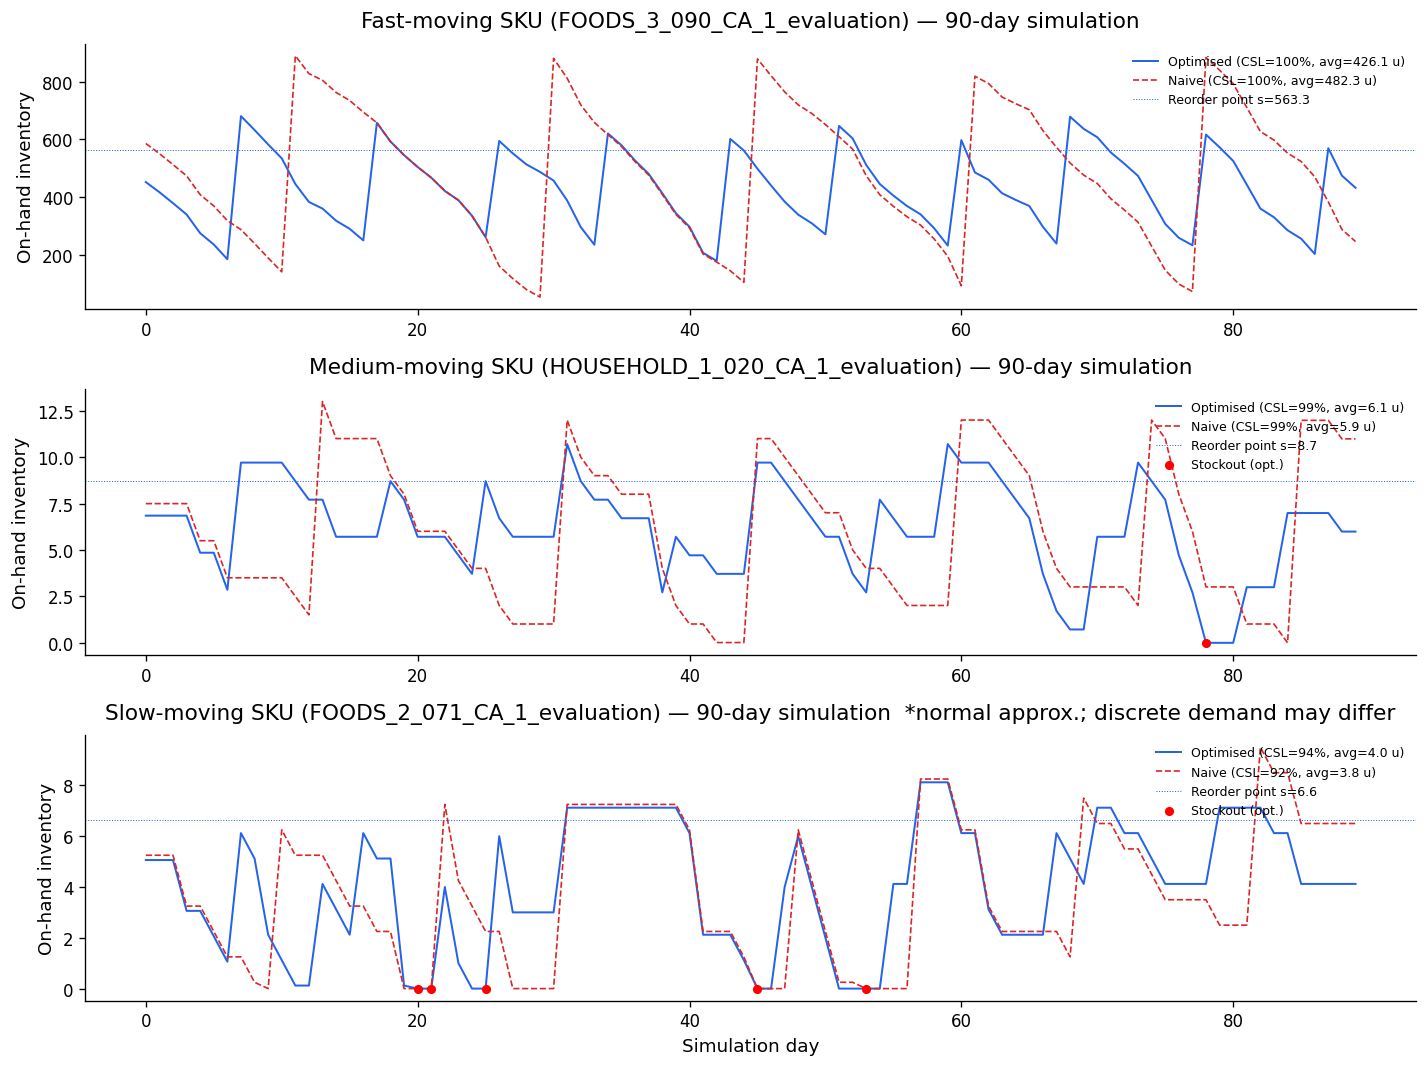

In [16]:
# Pick 3 representative SKUs: fast, medium, slow
fast_sku  = policies[policies["mean_daily_demand"] > 2].iloc[0]["id"]
med_sku   = policies.iloc[len(policies) // 2]["id"]
slow_sku  = policies[policies["mean_daily_demand"] < 0.5].iloc[0]["id"]
example_skus = [fast_sku, med_sku, slow_sku]
labels_skus  = ["Fast-moving", "Medium-moving", "Slow-moving"]

# Get actual demand for the last 90 days of training
SIM_DAYS = 90
train_tail = train.sort_values(["id", "date"]).groupby("id").tail(SIM_DAYS)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

summary_rows = []
for ax, sku_id, label in zip(axes, example_skus, labels_skus):
    sku_demand = (
        train_tail[train_tail["id"] == sku_id]
        .sort_values("date")["sales"].values
    )
    pol = policies[policies["id"] == sku_id].iloc[0]
    s_opt, S_opt = pol["reorder_point"], pol["order_up_to"]

    # Naive policy: no safety stock, larger replenishment order
    mu_d = pol["mean_daily_demand"]
    s_naive = mu_d * LEAD_TIME
    S_naive = s_naive + mu_d * 14

    sim_opt   = simulate_inventory(sku_demand, s_opt,   S_opt,   LEAD_TIME)
    sim_naive = simulate_inventory(sku_demand, s_naive, S_naive, LEAD_TIME)
    costs_opt   = compute_policy_costs(sim_opt)
    costs_naive = compute_policy_costs(sim_naive)

    summary_rows.append({"sku": label, "policy": "Optimised",
        "fill_rate": costs_opt["fill_rate"], "avg_on_hand": costs_opt["avg_on_hand"],
        "total_cost": costs_opt["total_cost"], "stockout_days": costs_opt["n_stockout_days"]})
    summary_rows.append({"sku": label, "policy": "Naive",
        "fill_rate": costs_naive["fill_rate"], "avg_on_hand": costs_naive["avg_on_hand"],
        "total_cost": costs_naive["total_cost"], "stockout_days": costs_naive["n_stockout_days"]})

    sl_note = "" if label != "Slow-moving" else "  *normal approx.; discrete demand may differ"
    days = np.arange(len(sku_demand))
    ax.plot(days, sim_opt["on_hand_after"],
            color=PALETTE[0], linewidth=1.2,
            label=f"Optimised (CSL={costs_opt['cycle_service_level']:.0%}, avg={costs_opt['avg_on_hand']:.1f} u)")
    ax.plot(days, sim_naive["on_hand_after"],
            color=PALETTE[2], linewidth=1.0, linestyle="--",
            label=f"Naive (CSL={costs_naive['cycle_service_level']:.0%}, avg={costs_naive['avg_on_hand']:.1f} u)")
    ax.axhline(s_opt, color=PALETTE[0], linewidth=0.6, linestyle=":",
               label=f"Reorder point s={s_opt:.1f}")

    stockout_days = sim_opt[sim_opt["stockout_units"] > 0].index
    if len(stockout_days):
        ax.scatter(stockout_days, np.zeros(len(stockout_days)),
                   color="red", s=20, zorder=5, label="Stockout (opt.)")

    ax.set_ylabel("On-hand inventory")
    ax.set_title(f"{label} SKU ({sku_id}) — 90-day simulation{sl_note}")
    ax.legend(fontsize=7.5, loc="upper right")

axes[-1].set_xlabel("Simulation day")
plt.tight_layout()
plt.savefig(RESULTS / "inventory_simulation.png", dpi=120)
plt.show()


Simulation summary: Optimised vs Naive policy
          sku    policy  fill_rate  avg_on_hand  total_cost  stockout_days
  Fast-moving Optimised      1.000      426.100  383706.550              0
  Fast-moving     Naive      1.000      482.260  434156.740              0
Medium-moving Optimised      0.996        6.130    5782.800              1
Medium-moving     Naive      0.985        5.930    5461.550              1
  Slow-moving Optimised      0.827        4.030    3967.400              5
  Slow-moving     Naive      0.754        3.840    3682.770              7


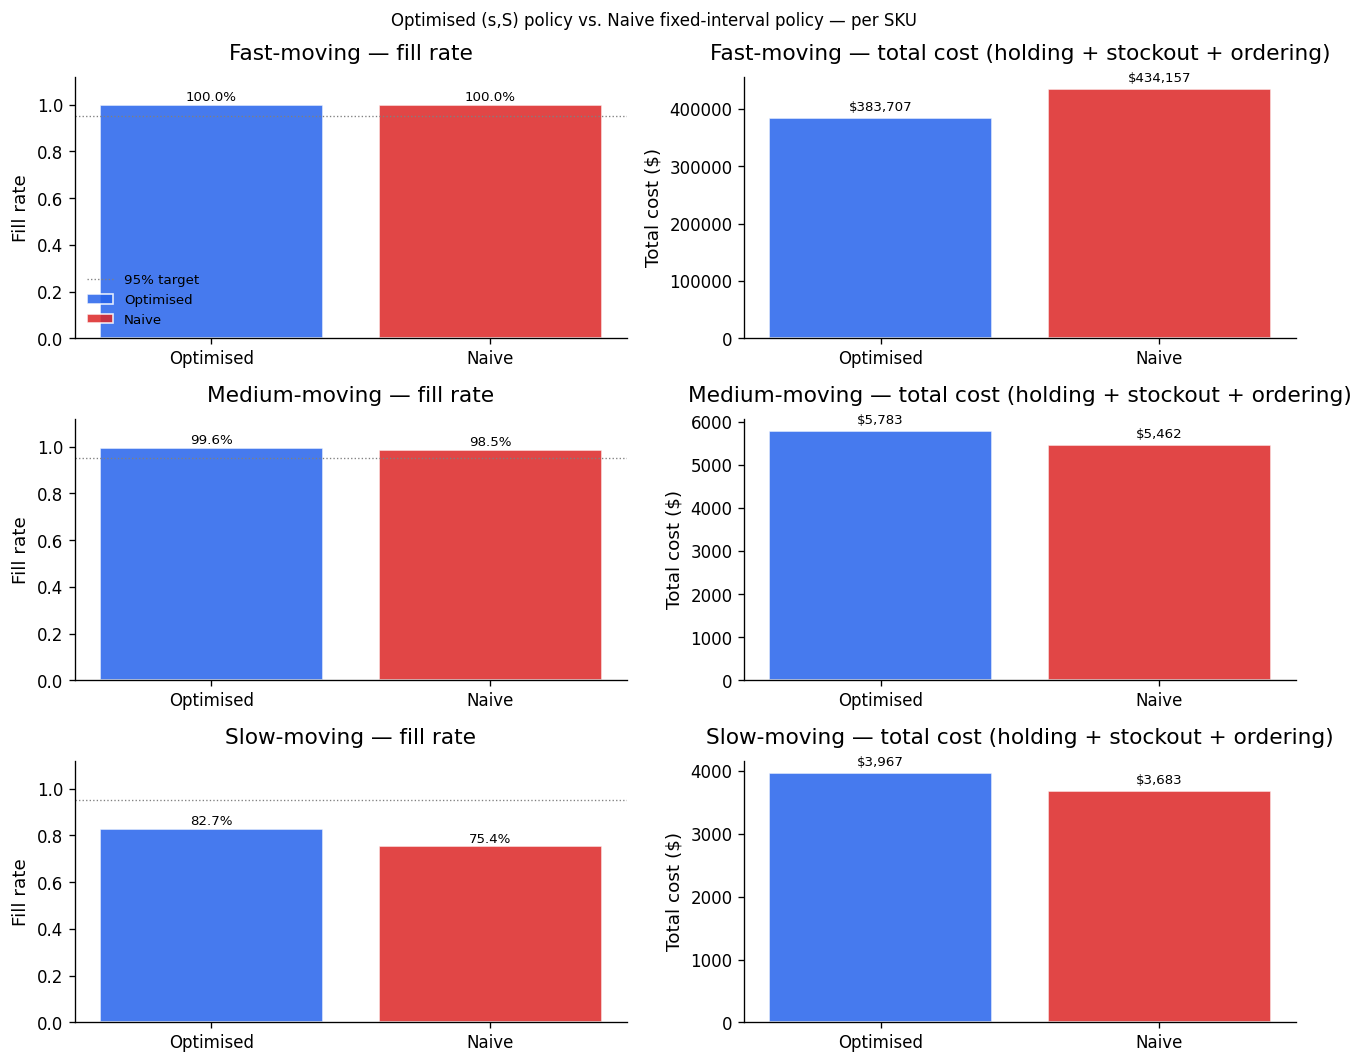


Cost savings (Naive - Optimised):
  Fast-moving    : $+50,450  (+11.6%)
  Medium-moving  : $-321  (-5.9%)
  Slow-moving    : $-285  (-7.7%)


In [17]:
summary_df = pd.DataFrame(summary_rows)
print("Simulation summary: Optimised vs Naive policy")
print(summary_df.to_string(index=False, float_format="%.3f"))

# One row per SKU so each gets its own y-axis scale
fig, axes = plt.subplots(len(labels_skus), 2, figsize=(11, 9))

colors = {"Optimised": PALETTE[0], "Naive": PALETTE[2]}
x = np.array([0, 1])

for row_i, sku_label in enumerate(labels_skus):
    sub = summary_df[summary_df["sku"] == sku_label]
    opt_row   = sub[sub["policy"] == "Optimised"].iloc[0]
    naive_row = sub[sub["policy"] == "Naive"].iloc[0]

    # Fill rate
    ax_fr = axes[row_i, 0]
    for j, (policy, row) in enumerate([("Optimised", opt_row), ("Naive", naive_row)]):
        bar = ax_fr.bar(j, row["fill_rate"], color=colors[policy], alpha=0.85,
                        edgecolor="white", label=policy)
        ax_fr.text(j, row["fill_rate"] + 0.005, f"{row['fill_rate']:.1%}",
                   ha="center", va="bottom", fontsize=8)
    ax_fr.set_ylim(0, 1.12)
    ax_fr.set_xticks([0, 1])
    ax_fr.set_xticklabels(["Optimised", "Naive"])
    ax_fr.set_ylabel("Fill rate")
    ax_fr.set_title(f"{sku_label} — fill rate")
    ax_fr.axhline(0.95, color="grey", linestyle=":", linewidth=0.8, label="95% target")
    if row_i == 0:
        ax_fr.legend(fontsize=8)

    # Total cost
    ax_tc = axes[row_i, 1]
    for j, (policy, row) in enumerate([("Optimised", opt_row), ("Naive", naive_row)]):
        ax_tc.bar(j, row["total_cost"], color=colors[policy], alpha=0.85, edgecolor="white")
        ax_tc.text(j, row["total_cost"] * 1.02, f"${row['total_cost']:,.0f}",
                   ha="center", va="bottom", fontsize=8)
    ax_tc.set_xticks([0, 1])
    ax_tc.set_xticklabels(["Optimised", "Naive"])
    ax_tc.set_ylabel("Total cost ($)")
    ax_tc.set_title(f"{sku_label} — total cost (holding + stockout + ordering)")

plt.suptitle("Optimised (s,S) policy vs. Naive fixed-interval policy — per SKU", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS / "inventory_policy_comparison.png", dpi=120)
plt.show()

# Print savings
print("\nCost savings (Naive - Optimised):")
for sku_label in labels_skus:
    sub = summary_df[summary_df["sku"] == sku_label]
    opt_c   = sub[sub["policy"] == "Optimised"]["total_cost"].iloc[0]
    naive_c = sub[sub["policy"] == "Naive"]["total_cost"].iloc[0]
    savings = naive_c - opt_c
    pct     = savings / naive_c * 100 if naive_c > 0 else 0
    print(f"  {sku_label:15s}: ${savings:+,.0f}  ({pct:+.1f}%)")


## 6. Newsvendor model: the cost-optimal order quantity

The newsvendor model finds the order quantity Q* that minimises expected cost
given the trade-off between overstocking (holding cost Co) and understocking
(lost margin Cu).

$$Q^* = \mu + z\left(\frac{C_u}{C_u + C_o}\right) \cdot \sigma$$

The **critical ratio** CR = Cu / (Cu + Co) determines the optimal service level.
With Co=1 and Cu=5, CR = 5/6 ≈ 0.833 → stock up to the 83rd percentile of demand.

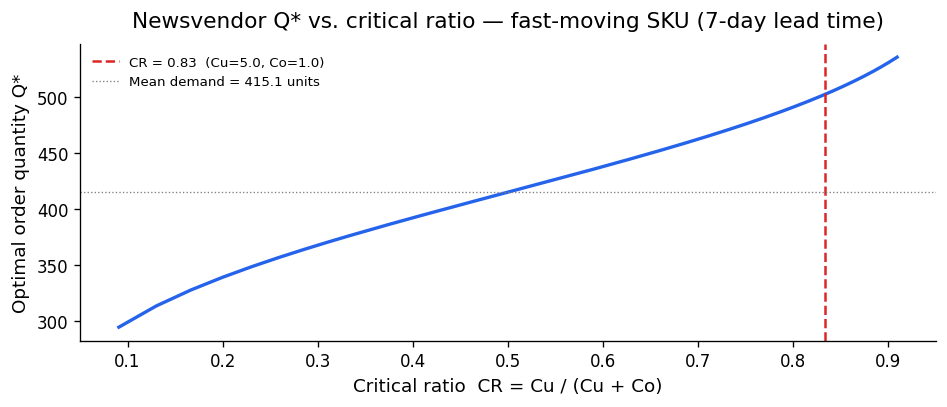

At CR=0.83: Q* = 502.3 units
Mean lead-time demand: 415.1 units — Q* is 121.0% of mean


In [18]:
# Show the newsvendor trade-off curve for the fast-moving SKU
fast_pol = policies[policies["id"] == fast_sku].iloc[0]
mu_f  = fast_pol["mean_daily_demand"] * LEAD_TIME   # lead-time demand
sig_f = fast_pol["std_daily_demand"] * np.sqrt(LEAD_TIME)

cost_ratios = np.linspace(0.1, 10, 200)  # Cu / Co ratios
q_stars = [
    newsvendor_quantity(mu_f, sig_f, cost_overstock=1.0, cost_understock=cr)
    for cr in cost_ratios
]
cr_values = cost_ratios / (cost_ratios + 1)  # Cu / (Cu + Co)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(cr_values, q_stars, color=PALETTE[0], linewidth=2)
ax.axvline(COST_UNDER / (COST_UNDER + COST_OVER), color=PALETTE[2],
           linestyle="--", label=f"CR = {COST_UNDER/(COST_UNDER+COST_OVER):.2f}  (Cu={COST_UNDER}, Co={COST_OVER})")
ax.axhline(mu_f, color="grey", linestyle=":", linewidth=0.8, label=f"Mean demand = {mu_f:.1f} units")
ax.set_xlabel("Critical ratio  CR = Cu / (Cu + Co)")
ax.set_ylabel("Optimal order quantity Q*")
ax.set_title(f"Newsvendor Q* vs. critical ratio — fast-moving SKU (7-day lead time)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "inventory_newsvendor.png", dpi=120)
plt.show()

print(f"At CR={COST_UNDER/(COST_UNDER+COST_OVER):.2f}: Q* = {newsvendor_quantity(mu_f, sig_f, COST_OVER, COST_UNDER):.1f} units")
print(f"Mean lead-time demand: {mu_f:.1f} units — Q* is {newsvendor_quantity(mu_f, sig_f, COST_OVER, COST_UNDER)/mu_f:.1%} of mean")

## 7. Summary

| What we built | Business value |
|---------------|----------------|
| σ from intervals | Translates ML uncertainty directly into inventory math — no separate demand modelling |
| (s, S) per SKU | ~3,000 personalised reorder policies in seconds; replaces one-size-fits-all rules |
| Service-level frontier | Makes the cost of availability explicit — supports data-driven SLA negotiations |
| Newsvendor Q* | Asymmetric cost structure; a $5 lost sale penalty pushes us to stock to the 83rd percentile |
| Simulation | Empirical validation that the policy achieves the target service level under real demand patterns |

**Limitations**:
- Independent demand across SKUs assumed (no substitution / cannibalism effects)
- Lead time treated as fixed; stochastic lead time would require wider safety stock
- Simulation uses historical demand — black-swan events (COVID, supply shocks) need scenario analysis
- Seasonality in the inventory policy (higher safety stock pre-holiday) not yet implemented

**Next**: `05_returns_intelligence.ipynb` — Project 02 begins.